In [23]:
from utils.dataset import dataset_prep
from omegaconf import OmegaConf

MAX_SAMPLES = 1000
dataset_cfg = OmegaConf.load("configs/dataset.yaml")
dataset_cfg.dataset.max_samples = MAX_SAMPLES # Overwrite max_samples for quick experimentation
ds = dataset_prep(dataset_cfg.dataset)
ds_train = ds["train"]

[23:01:45] Loaded dataset sh0416/ag_news with splits: dict_keys(['train', 'dev', 'test'])
[23:01:45] Preprocessing splits...
Map: 2000 examples [00:00, 24764.15 examples/s]        
Map: 2000 examples [00:00, 29660.38 examples/s]        
Map: 2000 examples [00:00, 29555.25 examples/s]        
[23:01:45] Detected 1-based labels (min=1, max=4); converting to 0-based indices
Map: 2000 examples [00:00, 53302.29 examples/s]        
Map: 2000 examples [00:00, 7396.34 examples/s]         
Map: 2000 examples [00:00, 52271.33 examples/s]        
[23:01:45] Dataset preprocessing complete. Sample from preprocessed dataset: {'labels': 3, 'title': "Sun's Linux wins right to be considered in Japan", 'description': "They're on a list, and they want to tell us all about it", 'text': "Sun's Linux wins right to be considered in Japan They're on a list, and they want to tell us all about it"}


In [24]:
ds_train[0]

{'labels': 3,
 'title': "Sun's Linux wins right to be considered in Japan",
 'description': "They're on a list, and they want to tell us all about it",
 'text': "Sun's Linux wins right to be considered in Japan They're on a list, and they want to tell us all about it"}

In [25]:
# frequency distribution of labels
from collections import Counter

label_counts = Counter(ds_train["labels"])
print(label_counts)

Counter({3: 256, 2: 251, 1: 248, 0: 245})


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sigurdurhaukur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


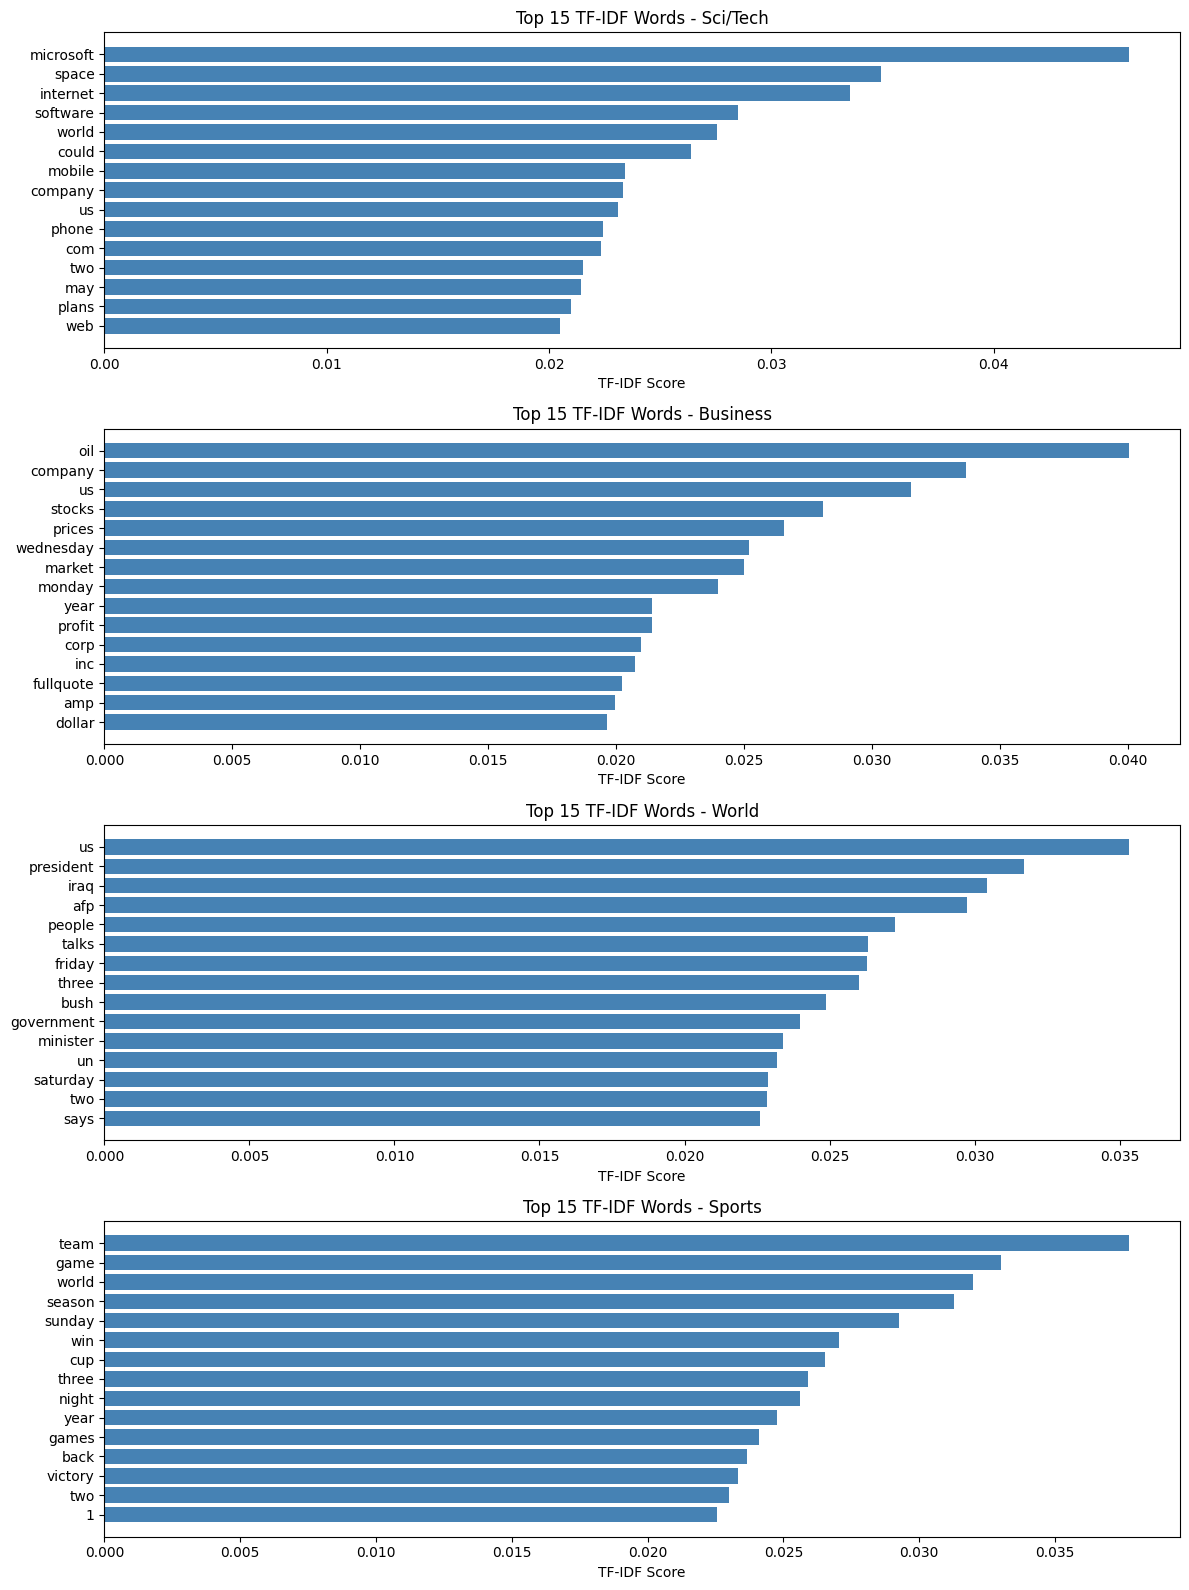

In [36]:
from collections import defaultdict, Counter
import nltk
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Add domain-specific stopwords
domain_stops = {"said", "new", "ap", "reuters", "quot", "one", "u", "n", "first"} # Words that "poisoned" the previous analysis
custom_stops = stop_words | domain_stops

# Prepare texts grouped by label
texts_by_label = defaultdict(list)
for text, label in zip(ds_train["text"], ds_train["labels"]):
    texts_by_label[label].append(text)

# Compute TF-IDF for each label
tfidf_scores = {}
for label, texts in texts_by_label.items():
    vectorizer = TfidfVectorizer(
        stop_words=list(custom_stops),
        token_pattern=r"\b\w+\b", # Keep only words (no punctuation)
        lowercase=True,
        max_features=5000,
        min_df=5, # Ignore words that appear in less than 5 documents
        max_df=0.8, # Ignore words that appear in more than 80% of documents
        ngram_range=(1, 2)
    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    # Average TF-IDF scores across documents
    avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    tfidf_scores[label] = list(zip(vocab, avg_tfidf))
    tfidf_scores[label].sort(key=lambda x: x[1], reverse=True)

# Plot distribution
num_labels = len(tfidf_scores)
fig, axes = plt.subplots(num_labels, 1, figsize=(12, 4 * num_labels))
if num_labels == 1:
    axes = [axes]

for idx, (label, scores) in enumerate(tfidf_scores.items()):
    label_str = dataset_cfg.dataset.label_mapping[label + 1]
    top_words = scores[:15]
    words, tfidf_vals = zip(*top_words)
    axes[idx].barh(words, tfidf_vals, color="steelblue")
    axes[idx].set_xlabel("TF-IDF Score")
    axes[idx].set_title(f"Top 15 TF-IDF Words - {label_str}")
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()


In [37]:
# Save TF-IDF scores per label to a file
import json

tfidf_output = {}
for label, scores in tfidf_scores.items():
    label_str = dataset_cfg.dataset.label_mapping[label + 1]
    tfidf_output[label_str] = [{"word": word, "score": score} for word, score in scores]

with open("tfidf_scores_by_label.json", "w") as f:
    json.dump(tfidf_output, f, indent=4)

In [39]:
# Load and print TF-IDF scores from file
with open("tfidf_scores_by_label.json", "r") as f:
    loaded_tfidf = json.load(f)

for label, word_scores in loaded_tfidf.items():
    print(f"Label: {label}")
    for entry in word_scores[:3]:  # Print top 3 words
        print(f"  Word: {entry['word']}, Score: {entry['score']:.4f}")
    print()

Label: Sci/Tech
  Word: microsoft, Score: 0.0461
  Word: space, Score: 0.0349
  Word: internet, Score: 0.0336

Label: Business
  Word: oil, Score: 0.0400
  Word: company, Score: 0.0337
  Word: us, Score: 0.0315

Label: World
  Word: us, Score: 0.0353
  Word: president, Score: 0.0317
  Word: iraq, Score: 0.0304

Label: Sports
  Word: team, Score: 0.0377
  Word: game, Score: 0.0330
  Word: world, Score: 0.0320



In [44]:
# Masking out top TF-IDF words from the test set and saving the modified dataset for later evaluation (keyword masking probing)
# --- mask_and_save.py ---
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab = tokenizer.get_vocab()
mask_token = tokenizer.mask_token if tokenizer.mask_token is not None else tokenizer.unk_token
max_len = tokenizer.model_max_length if tokenizer.model_max_length and tokenizer.model_max_length < 10000 else 512

ds_test = ds["test"]

TOP_N = 20
top_words = [word for word, _ in tfidf_scores[0][:TOP_N]]
pattern = re.compile(
    r"\b(" + "|".join(re.escape(w) for w in top_words) + r")\b", flags=re.IGNORECASE
)


def mask_text(example):
    masked = pattern.sub(mask_token, example["text"])
    return {"text": masked}


# Re-tokenize after masking so input_ids reflect the masked text
def tokenize(example):
    encoded = tokenizer(
        example["text"],
        add_special_tokens=False,
        truncation=True,
        max_length=max_len,
    )
    input_ids = encoded["input_ids"]
    input_ids = input_ids[:max_len] + [tokenizer.pad_token_id or 0] * max(0, max_len - len(input_ids))
    return {"input_ids": input_ids}


masked_ds = ds_test.map(mask_text)
masked_ds = masked_ds.map(tokenize)
masked_ds.save_to_disk("masked_test_set")

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 350870.34 examples/s]
